In [50]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from datetime import datetime as time
from typing import *
from IPython.display import HTML


# Предварительные вычисления

Функции из условия

In [36]:
def f(x: np.array) -> np.array:
  return np.sqrt(x)

def F(x: np.array) -> np.array:
  return x * x * x

Визуализация функций из услосвия

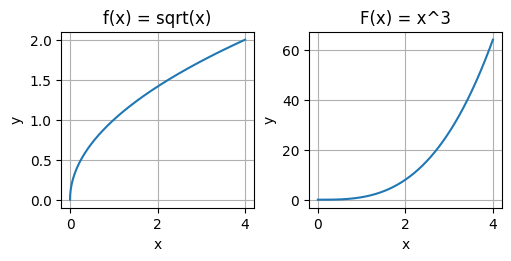

In [37]:
E = np.linspace(0, 4, 10000)
y_f = f(E)
y_F = F(E)

fig, (ax1, ax2) = plt.subplots(1, 2, layout='constrained', figsize=(5, 5/2))
ax1.set(xlabel='x', ylabel='y',
       title='f(x) = sqrt(x)')
ax2.set(xlabel='x', ylabel='y',
       title='F(x) = x^3')

ax1.plot(E, y_f)
ax1.grid()
ax2.plot(E, y_F)
ax2.grid()

plt.savefig("originals.pdf")
plt.show()

Простые функции (см п.1.2 отчета)

In [38]:
def get_simple_function(n: int) -> Callable[[np.array], np.array]:

    num_intervals = 2**n
    max_val = 2.0
    dy = max_val / num_intervals

    def fn(x: np.array) -> np.array:
        y = f(x)

        k = np.floor(y / dy)

        return k * dy

    return fn

Визуализизация простых функций

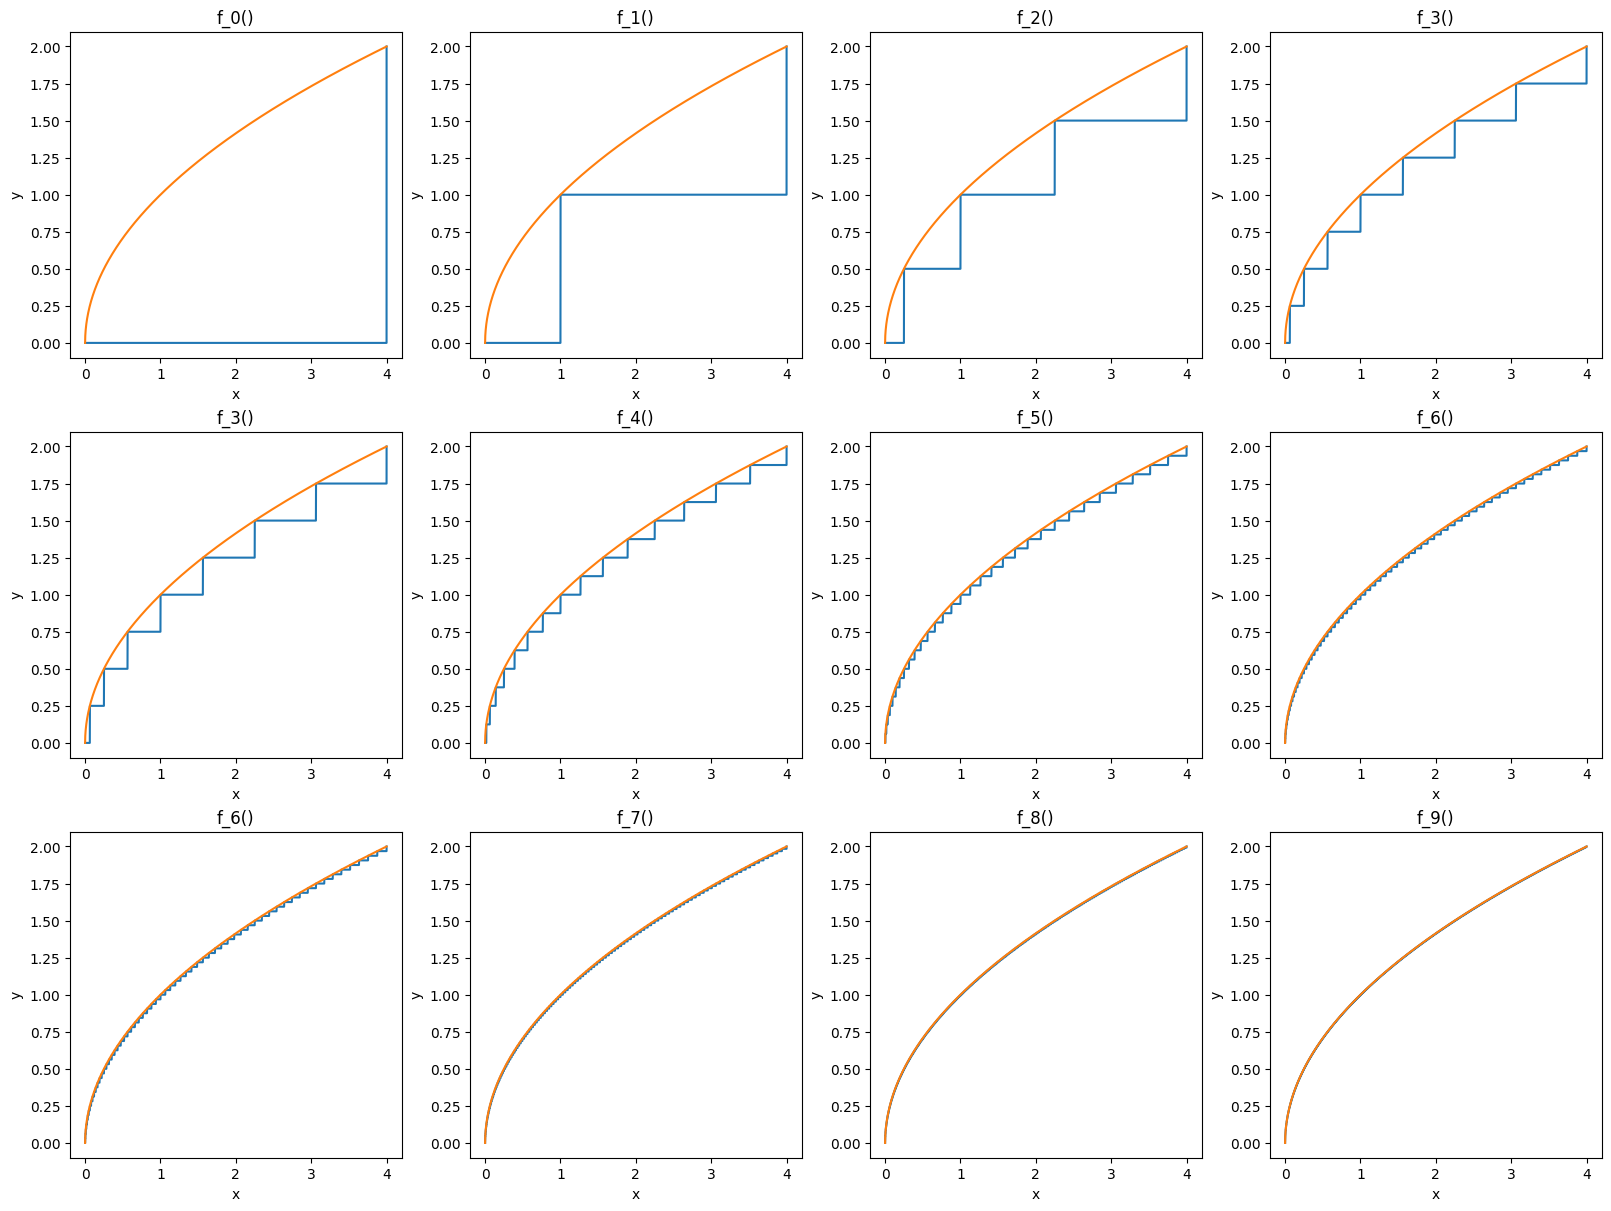

In [39]:
fig, axes = plt.subplots(3, 4, layout="constrained", figsize=(16, 12))

for i in range(len(axes)):
  for j in range(len(axes[i])):
    ax = axes[i][j]
    ax.set(xlabel="x", ylabel="y", title=f"f_{i * 3 + j}()")
    ax.plot(E, get_simple_function(i * 3 + j)(E))
    ax.plot(E, f(E))

plt.savefig("simple_functions.pdf")
plt.show()

Интеграл Лебега

In [40]:
def compute_lebesgue_integral(fn: Callable) -> float:
    global E
    dx = E[1] - E[0]

    y_vals = fn(E)

    return np.sum(y_vals) * dx

Интеграл Лебега-Стилтьеса

In [41]:
def compute_stieltjes_integral(fn: Callable) -> float:
    global E
    dx = E[1] - E[0]

    y_fn = fn(E)

    F_vals = F(E)
    dF = np.diff(F_vals, prepend=F_vals[0])

    integral = np.sum(y_fn[:-1] * np.diff(F_vals))

    return integral

# Основные вычисления

Аналитический интеграл Лебега: 5.333333333333
Аналитический интеграл Стилтьеса: 109.714285714286
------------------------------


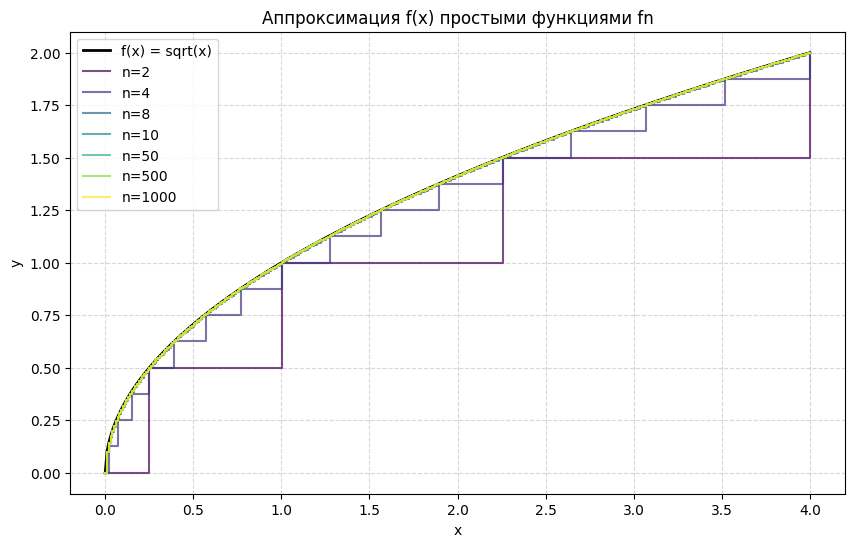

n       & Leb(fn)           & Err Leb      & Stielt(fn)        & Err St       & time          
-----------------------------------------------------------------
$2    $ & $4.250000625000 $ & $1.08e+00  $ & $89.796873139062$ & $1.99e+01  $ & $0.378902    $
$4    $ & $5.078125457813 $ & $2.55e-01  $ & $105.464607697659$ & $4.25e+00  $ & $0.387829    $
$8    $ & $5.317688384894 $ & $1.56e-02  $ & $109.463305171491$ & $2.51e-01  $ & $0.431976    $
$10   $ & $5.329426214193 $ & $3.91e-03  $ & $109.651720730146$ & $6.26e-02  $ & $0.405747    $
$50   $ & $5.333333733281 $ & $4.00e-07  $ & $109.714281874285$ & $3.84e-06  $ & $0.425847    $
$500  $ & $5.333333733281 $ & $4.00e-07  $ & $109.714281874285$ & $3.84e-06  $ & $0.418219    $
$1000 $ & $5.333333733281 $ & $4.00e-07  $ & $109.714281874285$ & $3.84e-06  $ & $0.454873    $


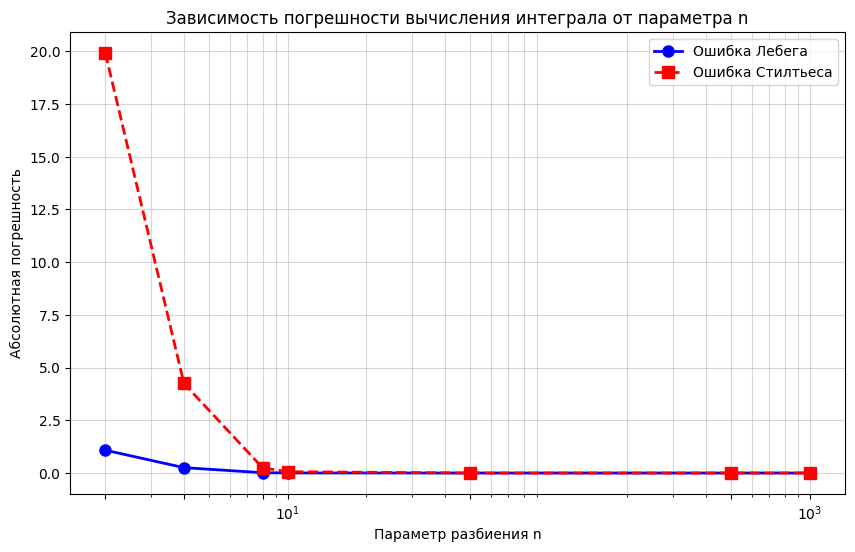

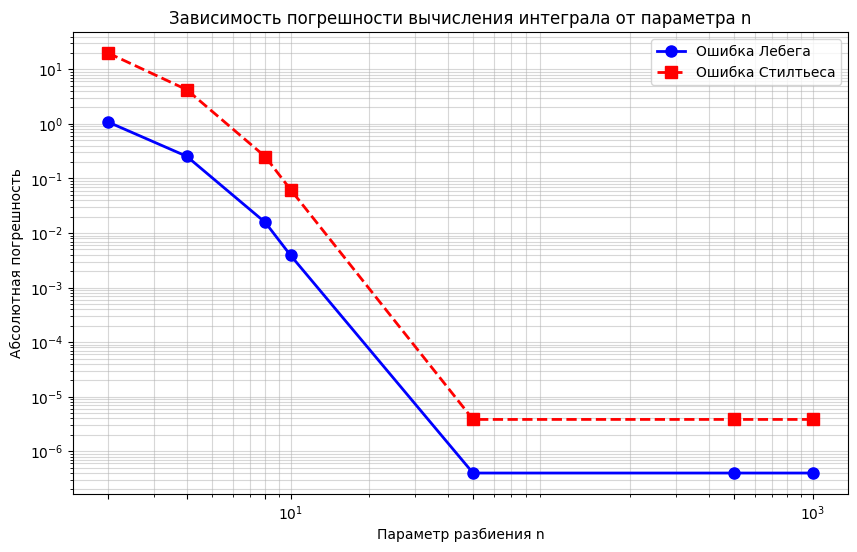

In [52]:
ANALYTICAL_LEBESGUE = 16/3
ANALYTICAL_STIELTJES = 768/7

print(f"Аналитический интеграл Лебега: {ANALYTICAL_LEBESGUE:.12f}")
print(f"Аналитический интеграл Стилтьеса: {ANALYTICAL_STIELTJES:.12f}")
print("-" * 30)

n_values = [2, 4, 8, 10, 50, 500, 1000]
# n_values = np.logspace(0, 3, num=20).astype(int).tolist()

E = np.linspace(0, 4, 10000000)

results_lebesgue = []
results_stieltjes = []

x_plot = np.linspace(0, 4, 400)
y_true = f(x_plot)

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_true, 'k-', linewidth=2, label='f(x) = sqrt(x)')

colors = plt.cm.viridis(np.linspace(0, 1, len(n_values)))
for i, n in enumerate(n_values):
    fn = get_simple_function(n)
    y_fn = fn(x_plot)
    plt.step(x_plot, y_fn, where='post', label=f'n={n}', color=colors[i], alpha=0.7)

plt.title('Аппроксимация f(x) простыми функциями fn')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


print(f"{'n':<7} & {'Leb(fn)':<17} & {'Err Leb':<12} & {'Stielt(fn)':<17} & {'Err St':<12} & {'time':<14}")
timestamp = time.now()
print("-" * 65)

for n in n_values:
    fn = get_simple_function(n)

    int_leb = compute_lebesgue_integral(fn)
    int_st = compute_stieltjes_integral(fn)

    err_leb = abs(int_leb - ANALYTICAL_LEBESGUE)
    err_st = abs(int_st - ANALYTICAL_STIELTJES)

    results_lebesgue.append((n, int_leb))
    results_stieltjes.append((n, int_st))

    calc = time.now() - timestamp
    print(f"${n:<5}$ & ${int_leb:<15.12f}$ & ${err_leb:<10.2e}$ & ${int_st:<15.12f}$ & ${err_st:<10.2e}$ & ${calc.total_seconds():<12}$")
    timestamp = time.now()

n_vals_leb, err_vals_leb = zip(*[(n, abs(val - ANALYTICAL_LEBESGUE)) for n, val in results_lebesgue])
n_vals_st, err_vals_st = zip(*[(n, abs(val - ANALYTICAL_STIELTJES)) for n, val in results_stieltjes])

plt.figure(figsize=(10, 6))

plt.semilogx(n_vals_leb, err_vals_leb, 'bo-', label='Ошибка Лебега', linewidth=2, markersize=8)

plt.semilogx(n_vals_st, err_vals_st, 'rs--', label='Ошибка Стилтьеса', linewidth=2, markersize=8)

plt.title('Зависимость погрешности вычисления интеграла от параметра n')
plt.xlabel('Параметр разбиения n')
plt.ylabel('Абсолютная погрешность')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.xticks(n_vals_leb)
plt.savefig("errors.pdf")
plt.show()

plt.figure(figsize=(10, 6))

plt.loglog(n_vals_leb, err_vals_leb, 'bo-', label='Ошибка Лебега', linewidth=2, markersize=8)

plt.loglog(n_vals_st, err_vals_st, 'rs--', label='Ошибка Стилтьеса', linewidth=2, markersize=8)

plt.title('Зависимость погрешности вычисления интеграла от параметра n')
plt.xlabel('Параметр разбиения n')
plt.ylabel('Абсолютная погрешность')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.xticks(n_vals_leb)
plt.savefig("errors_log.pdf")
plt.show()


Дополнительно - анимированная визуализация

In [ ]:
n_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 100, 500, 1000]
frames_count = len(n_values)
x_plot = np.linspace(0, 4, 1000)
y_true = f(x_plot)


fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 4)
ax.set_ylim(0, 2.5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Аппроксимация f(x) = sqrt(x) простыми функциями fn(x)')
ax.grid(True, linestyle='--', alpha=0.5)


line_true, = ax.plot(x_plot, y_true, 'k-', linewidth=2, label='f(x) = sqrt(x)')

line_fn, = ax.step([], [], 'r-', where='post', linewidth=1.5, label='fn(x)')

ax.legend(loc='lower right')


text_info = ax.text(0.05, 0.95, '', transform=ax.transAxes, fontsize=12,
                    verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.5))

def init():
    line_fn.set_data([], [])
    text_info.set_text('')
    return line_fn, text_info

def animate(i):
    n = n_values[i]
    fn = get_simple_function(n)
    y_fn = fn(x_plot)


    line_fn.set_data(x_plot, y_fn)


    int_leb = compute_lebesgue_integral(fn)
    error = abs(int_leb - ANALYTICAL_LEBESGUE)


    text_info.set_text(f'n = {n}\nИнтеграл fn: {int_leb:.5f}\nОшибка: {error:.2e}')

    return line_fn, text_info


ani = animation.FuncAnimation(fig, animate, frames=range(0, frames_count),
                              init_func=init, blit=True, interval=500, repeat_delay=2000)

plt.close()
HTML(ani.to_jshtml())